#**Cardiomegaly Pulmonary Diseases**
__________________________________________________________
__________________________________________________________
__________________________________________________________

In [ ]:
import os, random, time, json
import numpy as np
import torch, torch.nn as nn
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
from PIL import Image
from glob import glob

In [ ]:
base_path = "/content/drive/MyDrive/LLM-NIH"

In [ ]:
import os
import pandas as pd
import glob
from google.colab import drive

drive.mount('/content/drive')

base_path = "/content/drive/MyDrive/LLM-NIH"
print("Files in folder:")
print(os.listdir(base_path))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Files in folder:
['Data_Entry_2017_v2020.csv', 'mimic_llm_annotations.csv', 'nih_llm_annotations_val.csv', 'nih_llm_annotations_test.csv', 'nih_llm_annotations_train.csv', 'Untitled0.ipynb']


In [ ]:
nih_df = pd.read_csv(f"{base_path}/Data_Entry_2017_v2020.csv")
train_llm = pd.read_csv(f"{base_path}/nih_llm_annotations_train.csv")
val_llm = pd.read_csv(f"{base_path}/nih_llm_annotations_val.csv")

print("NIH shape:", nih_df.shape)
print("Train LLM shape:", train_llm.shape)
print("Val LLM shape:", val_llm.shape)

NIH shape: (112120, 11)
Train LLM shape: (314024, 15)
Val LLM shape: (32072, 15)


In [ ]:
print("NIH columns:")
print(nih_df.columns.tolist())

print("\nTrain LLM columns:")
print(train_llm.columns.tolist())

print("\nVal LLM columns:")
print(val_llm.columns.tolist())

NIH columns:
['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Sex', 'View Position', 'OriginalImage[Width', 'Height]', 'OriginalImagePixelSpacing[x', 'y]']

Train LLM columns:
['subjectid_studyid', 'type_annotation', 'enlarged cardiomediastinum', 'cardiomegaly', 'atelectasis', 'consolidation', 'lung edema', 'fracture', 'lung lesion', 'pleural effusion', 'pneumonia', 'pneumothorax', 'support device', 'lung opacity', 'pleural other']

Val LLM columns:
['subjectid_studyid', 'type_annotation', 'enlarged cardiomediastinum', 'cardiomegaly', 'atelectasis', 'consolidation', 'lung edema', 'fracture', 'lung lesion', 'pleural effusion', 'pneumonia', 'pneumothorax', 'support device', 'lung opacity', 'pleural other']


In [ ]:
 for item in os.listdir(base_path):
    print(item)

Data_Entry_2017_v2020.csv
mimic_llm_annotations.csv
nih_llm_annotations_val.csv
nih_llm_annotations_test.csv
nih_llm_annotations_train.csv
Untitled0.ipynb


In [ ]:
image_root = f"{base_path}/images"
all_images = glob.glob(os.path.join(image_root, "**", "*.png"), recursive=True)

print("Number of PNG images found:", len(all_images))
print(all_images[:5])

Number of PNG images found: 0
[]


In [ ]:
path_dict = {os.path.basename(x): x for x in all_images}
print("Unique image filenames mapped:", len(path_dict))

Unique image filenames mapped: 0


In [ ]:
nih_df["path"] = nih_df["Image Index"].map(path_dict)

print("Rows with matched paths:", nih_df["path"].notna().sum())
display(nih_df[["Image Index", "path"]].head())

Rows with matched paths: 0


,Image Index,path
0,00000001_000.png,NaN
1,00000001_001.png,NaN
2,00000001_002.png,NaN
3,00000002_000.png,NaN
4,00000003_001.png,NaN


In [ ]:
def process_labels(label_string):
    return [x.strip() for x in str(label_string).split("|")]

nih_df["labels_list"] = nih_df["Finding Labels"].apply(process_labels)

nih_df["is_cardio"] = nih_df["labels_list"].apply(lambda x: 1 if "Cardiomegaly" in x else 0)
nih_df["is_no_finding"] = nih_df["labels_list"].apply(lambda x: 1 if x == ["No Finding"] else 0)

filtered_df = nih_df[(nih_df["is_cardio"] == 1) | (nih_df["is_no_finding"] == 1)].copy()
filtered_df["target"] = filtered_df["is_cardio"]

print(filtered_df["target"].value_counts())
display(filtered_df[["Image Index", "Finding Labels", "Patient ID", "Patient Gender", "Patient Age", "target"]].head())

target
0    60361
1     2776
Name: count, dtype: int64


KeyError: "['Patient Gender'] not in index"

In [ ]:
print(filtered_df.groupby("Patient Gender")["target"].value_counts())

KeyError: 'Patient Gender'

In [ ]:
positive_df = filtered_df[filtered_df["target"] == 1].copy()
negative_df = filtered_df[filtered_df["target"] == 0].copy()

negative_sampled = negative_df.sample(n=len(positive_df), random_state=42)

balanced_df = pd.concat([positive_df, negative_sampled], axis=0)\
                .sample(frac=1, random_state=42)\
                .reset_index(drop=True)

print(balanced_df["target"].value_counts())
print("Balanced shape:", balanced_df.shape)

target
1    2776
0    2776
Name: count, dtype: int64
Balanced shape: (5552, 16)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(balanced_df, groups=balanced_df["Patient ID"]))

train_df = balanced_df.iloc[train_idx].copy()
temp_df = balanced_df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["Patient ID"]))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain target counts:")
print(train_df["target"].value_counts())

print("\nVal target counts:")
print(val_df["target"].value_counts())

print("\nTest target counts:")
print(test_df["target"].value_counts())

Train: (4429, 16)
Val: (570, 16)
Test: (553, 16)

Train target counts:
target
0    2232
1    2197
Name: count, dtype: int64

Val target counts:
target
1    297
0    273
Name: count, dtype: int64

Test target counts:
target
1    282
0    271
Name: count, dtype: int64


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("simhadrisadaram/mimic-cxr-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mimic-cxr-dataset' dataset.
Path to dataset files: /kaggle/input/mimic-cxr-dataset


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print("Files:", files[:5])
    break

/kaggle/input/mimic-cxr-dataset
Files: ['mimic_cxr_aug_validate.csv', 'mimic_cxr_aug_train.csv']


In [ ]:
import glob

all_images = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)

print("Number of images:", len(all_images))
print(all_images[:5])

KeyboardInterrupt: 

In [ ]:
import pandas as pd
import os
import glob

base_path = "/content/drive/MyDrive/LLM-NIH"
mimic_llm = pd.read_csv(f"{base_path}/mimic_llm_annotations.csv")

print(mimic_llm.shape)
print(mimic_llm.columns.tolist())
display(mimic_llm.head())

(911308, 15)
['subjectid_studyid', 'type_annotation', 'enlarged cardiomediastinum', 'consolidation', 'pleural other', 'lung lesion', 'cardiomegaly', 'lung opacity', 'atelectasis', 'lung edema', 'fracture', 'pleural effusion', 'pneumonia', 'pneumothorax', 'support device']


,subjectid_studyid,type_annotation,enlarged cardiomediastinum,consolidation,pleural other,lung lesion,cardiomegaly,lung opacity,atelectasis,lung edema,fracture,pleural effusion,pneumonia,pneumothorax,support device
0,10000032_50414267,labels,0,0,0,0,0,0,-2,-2,1,0,0,0,-2
1,10000032_50414267,location,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,10000032_50414267,probability,0,0,1,1,0,1,1,0,0,1,0,1,0
3,10000032_50414267,severity,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,10000032_53189527,labels,0,0,0,0,0,0,0,0,1,0,-2,0,-2


In [ ]:
mimic_train = pd.read_csv(f"{path}/mimic_cxr_aug_train.csv")
mimic_val = pd.read_csv(f"{path}/mimic_cxr_aug_validate.csv")

print("Train shape:", mimic_train.shape)
print("Val shape:", mimic_val.shape)

print("\nTrain columns:")
print(mimic_train.columns.tolist())

print("\nVal columns:")
print(mimic_val.columns.tolist())

display(mimic_train.head())
display(mimic_val.head())

Train shape: (64586, 10)
Val shape: (500, 10)

Train columns:
['Unnamed: 0.1', 'Unnamed: 0', 'subject_id', 'image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment']

Val columns:
['Unnamed: 0.1', 'Unnamed: 0', 'subject_id', 'image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment']


,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,0,10000032,['files/p10/p10000032/s50414267/02aa804e-bde0a...,"['PA', 'LATERAL', 'AP']",['files/p10/p10000032/s53911762/68b5c4b1-227d0...,['files/p10/p10000032/s50414267/02aa804e-bde0a...,['files/p10/p10000032/s50414267/174413ec-4ec4c...,"['Findings: There is no focal consolidation, p...","['Findings: There is no focus, pleural effusio..."
1,1,1,10000764,['files/p10/p10000764/s57375967/096052b7-d256d...,"['AP', 'LATERAL']",['files/p10/p10000764/s57375967/096052b7-d256d...,[],['files/p10/p10000764/s57375967/b79e55c3-735ce...,['Findings: PA and lateral views of the chest ...,['Finds: PA and lateral view of the breast int...
2,2,2,10000898,['files/p10/p10000898/s50771383/0c4eb1e1-b8019...,"['LATERAL', 'PA']",[],['files/p10/p10000898/s50771383/2a280266-c8bae...,['files/p10/p10000898/s50771383/0c4eb1e1-b8019...,['Findings: PA and lateral views of the chest ...,['Finds: PA and side view of the chest provide...
3,3,3,10000935,['files/p10/p10000935/s50578979/d0b71acc-b5a62...,"['AP', 'LATERAL', 'LL', 'PA']",['files/p10/p10000935/s50578979/d0b71acc-b5a62...,['files/p10/p10000935/s55697293/c50494f1-90e2b...,['files/p10/p10000935/s51178377/3be619d1-506a6...,['Findings: Lung volumes remain low. There ar...,['Results: Pulmonary volumes remain low. There...
4,4,4,10000980,['files/p10/p10000980/s50985099/6ad03ed1-97ee1...,"['PA', 'LL', 'AP', 'LATERAL']",['files/p10/p10000980/s51967283/943486a3-b3fa9...,['files/p10/p10000980/s50985099/6ad03ed1-97ee1...,['files/p10/p10000980/s54577367/96f9a77c-59b47...,['Findings: Impression: Compared to chest rad...,['Findings: Impression: Compared to the thorac...


,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,30,10003502,['files/p10/p10003502/s50084553/70d7e600-373c1...,"['AP', 'LATERAL', 'LL', 'PA']",['files/p10/p10003502/s50084553/70d7e600-373c1...,['files/p10/p10003502/s57812613/1efa55e3-0a385...,['files/p10/p10003502/s51180958/a8319f39-9eef5...,['Findings: Impression: Compared to chest rad...,['Results: Impression: Compared with thorax ra...
1,1,91,10013502,['files/p10/p10013502/s54857277/5c531aa1-a70cc...,"['PA', 'LL']",[],['files/p10/p10013502/s54857277/5c531aa1-a70cc...,[],"['Findings: Impression: ', 'Findings: Low lun...","['Results: Impression:', 'Testimonies: Low lun..."
2,2,369,10057482,['files/p10/p10057482/s52168780/5799175e-c125d...,"['LL', 'nan']",[],[],[],['Findings: No previous images. There are rel...,['Finds: No previous images. There are relativ...
3,3,459,10072167,['files/p10/p10072167/s50281931/537d5240-7ea88...,"['LATERAL', 'PA', 'LL']",[],['files/p10/p10072167/s50281931/822ea266-47279...,['files/p10/p10072167/s50281931/537d5240-7ea88...,['Findings: As compared to the previous radiog...,['Findings: There is no relevant change compar...
4,4,482,10075925,['files/p10/p10075925/s51010496/2d783c8a-49298...,"['PA', 'LATERAL']",[],['files/p10/p10075925/s51010496/2d783c8a-49298...,['files/p10/p10075925/s51010496/4cfccdcb-122ee...,['Findings: Mild pulmonary vascular congestion...,"['Results: Mild pulmonary vascular overload, w..."


In [ ]:
all_images = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)

print("Number of JPG images found:", len(all_images))
print(all_images[:5])

jpg_dict = {os.path.basename(x): x for x in all_images}
print("Unique JPG basenames:", len(jpg_dict))

KeyboardInterrupt: 

In [ ]:
print(mimic_llm.columns.tolist())
display(mimic_llm.head(10))

['subjectid_studyid', 'type_annotation', 'enlarged cardiomediastinum', 'consolidation', 'pleural other', 'lung lesion', 'cardiomegaly', 'lung opacity', 'atelectasis', 'lung edema', 'fracture', 'pleural effusion', 'pneumonia', 'pneumothorax', 'support device']


,subjectid_studyid,type_annotation,enlarged cardiomediastinum,consolidation,pleural other,lung lesion,cardiomegaly,lung opacity,atelectasis,lung edema,fracture,pleural effusion,pneumonia,pneumothorax,support device
0,10000032_50414267,labels,0,0,0,0,0,0,-2,-2,1,0,0,0,-2
1,10000032_50414267,location,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,10000032_50414267,probability,0,0,1,1,0,1,1,0,0,1,0,1,0
3,10000032_50414267,severity,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,10000032_53189527,labels,0,0,0,0,0,0,0,0,1,0,-2,0,-2
5,10000032_53189527,location,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
6,10000032_53189527,probability,0,0,1,0,0,1,1,0,100,0,0,0,0
7,10000032_53189527,severity,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
8,10000032_53911762,labels,0,0,0,0,0,0,-2,-2,1,0,-2,0,-2
9,10000032_53911762,location,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1


In [ ]:
print(mimic_llm.columns.tolist())
display(mimic_llm.head())

print(mimic_train.columns.tolist())
display(mimic_train.head())

print(mimic_val.columns.tolist())
display(mimic_val.head())

['subjectid_studyid', 'type_annotation', 'enlarged cardiomediastinum', 'consolidation', 'pleural other', 'lung lesion', 'cardiomegaly', 'lung opacity', 'atelectasis', 'lung edema', 'fracture', 'pleural effusion', 'pneumonia', 'pneumothorax', 'support device']


,subjectid_studyid,type_annotation,enlarged cardiomediastinum,consolidation,pleural other,lung lesion,cardiomegaly,lung opacity,atelectasis,lung edema,fracture,pleural effusion,pneumonia,pneumothorax,support device
0,10000032_50414267,labels,0,0,0,0,0,0,-2,-2,1,0,0,0,-2
1,10000032_50414267,location,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
2,10000032_50414267,probability,0,0,1,1,0,1,1,0,0,1,0,1,0
3,10000032_50414267,severity,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1,-1
4,10000032_53189527,labels,0,0,0,0,0,0,0,0,1,0,-2,0,-2


['Unnamed: 0.1', 'Unnamed: 0', 'subject_id', 'image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment']


,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,0,10000032,['files/p10/p10000032/s50414267/02aa804e-bde0a...,"['PA', 'LATERAL', 'AP']",['files/p10/p10000032/s53911762/68b5c4b1-227d0...,['files/p10/p10000032/s50414267/02aa804e-bde0a...,['files/p10/p10000032/s50414267/174413ec-4ec4c...,"['Findings: There is no focal consolidation, p...","['Findings: There is no focus, pleural effusio..."
1,1,1,10000764,['files/p10/p10000764/s57375967/096052b7-d256d...,"['AP', 'LATERAL']",['files/p10/p10000764/s57375967/096052b7-d256d...,[],['files/p10/p10000764/s57375967/b79e55c3-735ce...,['Findings: PA and lateral views of the chest ...,['Finds: PA and lateral view of the breast int...
2,2,2,10000898,['files/p10/p10000898/s50771383/0c4eb1e1-b8019...,"['LATERAL', 'PA']",[],['files/p10/p10000898/s50771383/2a280266-c8bae...,['files/p10/p10000898/s50771383/0c4eb1e1-b8019...,['Findings: PA and lateral views of the chest ...,['Finds: PA and side view of the chest provide...
3,3,3,10000935,['files/p10/p10000935/s50578979/d0b71acc-b5a62...,"['AP', 'LATERAL', 'LL', 'PA']",['files/p10/p10000935/s50578979/d0b71acc-b5a62...,['files/p10/p10000935/s55697293/c50494f1-90e2b...,['files/p10/p10000935/s51178377/3be619d1-506a6...,['Findings: Lung volumes remain low. There ar...,['Results: Pulmonary volumes remain low. There...
4,4,4,10000980,['files/p10/p10000980/s50985099/6ad03ed1-97ee1...,"['PA', 'LL', 'AP', 'LATERAL']",['files/p10/p10000980/s51967283/943486a3-b3fa9...,['files/p10/p10000980/s50985099/6ad03ed1-97ee1...,['files/p10/p10000980/s54577367/96f9a77c-59b47...,['Findings: Impression: Compared to chest rad...,['Findings: Impression: Compared to the thorac...


['Unnamed: 0.1', 'Unnamed: 0', 'subject_id', 'image', 'view', 'AP', 'PA', 'Lateral', 'text', 'text_augment']


,Unnamed: 0.1,Unnamed: 0,subject_id,image,view,AP,PA,Lateral,text,text_augment
0,0,30,10003502,['files/p10/p10003502/s50084553/70d7e600-373c1...,"['AP', 'LATERAL', 'LL', 'PA']",['files/p10/p10003502/s50084553/70d7e600-373c1...,['files/p10/p10003502/s57812613/1efa55e3-0a385...,['files/p10/p10003502/s51180958/a8319f39-9eef5...,['Findings: Impression: Compared to chest rad...,['Results: Impression: Compared with thorax ra...
1,1,91,10013502,['files/p10/p10013502/s54857277/5c531aa1-a70cc...,"['PA', 'LL']",[],['files/p10/p10013502/s54857277/5c531aa1-a70cc...,[],"['Findings: Impression: ', 'Findings: Low lun...","['Results: Impression:', 'Testimonies: Low lun..."
2,2,369,10057482,['files/p10/p10057482/s52168780/5799175e-c125d...,"['LL', 'nan']",[],[],[],['Findings: No previous images. There are rel...,['Finds: No previous images. There are relativ...
3,3,459,10072167,['files/p10/p10072167/s50281931/537d5240-7ea88...,"['LATERAL', 'PA', 'LL']",[],['files/p10/p10072167/s50281931/822ea266-47279...,['files/p10/p10072167/s50281931/537d5240-7ea88...,['Findings: As compared to the previous radiog...,['Findings: There is no relevant change compar...
4,4,482,10075925,['files/p10/p10075925/s51010496/2d783c8a-49298...,"['PA', 'LATERAL']",[],['files/p10/p10075925/s51010496/2d783c8a-49298...,['files/p10/p10075925/s51010496/4cfccdcb-122ee...,['Findings: Mild pulmonary vascular congestion...,"['Results: Mild pulmonary vascular overload, w..."


In [ ]:
labels_df = mimic_llm[mimic_llm["type_annotation"] == "labels"].copy()
print(labels_df.shape)
display(labels_df.head())

(227827, 15)


,subjectid_studyid,type_annotation,enlarged cardiomediastinum,consolidation,pleural other,lung lesion,cardiomegaly,lung opacity,atelectasis,lung edema,fracture,pleural effusion,pneumonia,pneumothorax,support device
0,10000032_50414267,labels,0,0,0,0,0,0,-2,-2,1,0,0,0,-2
4,10000032_53189527,labels,0,0,0,0,0,0,0,0,1,0,-2,0,-2
8,10000032_53911762,labels,0,0,0,0,0,0,-2,-2,1,0,-2,0,-2
12,10000032_56699142,labels,0,0,0,0,0,0,0,0,1,0,0,0,-2
16,10000764_57375967,labels,0,1,1,-2,0,1,-2,-2,-2,-2,-1,-2,-2


In [ ]:
labels_df[["subject_id", "study_id"]] = labels_df["subjectid_studyid"].str.split("_", expand=True)
labels_df["subject_id"] = labels_df["subject_id"].astype(str)
labels_df["study_id"] = labels_df["study_id"].astype(str)

display(labels_df[["subjectid_studyid", "subject_id", "study_id", "cardiomegaly"]].head())

,subjectid_studyid,subject_id,study_id,cardiomegaly
0,10000032_50414267,10000032,50414267,0
4,10000032_53189527,10000032,53189527,0
8,10000032_53911762,10000032,53911762,0
12,10000032_56699142,10000032,56699142,0
16,10000764_57375967,10000764,57375967,0


In [ ]:
import os
import glob
import pandas as pd

all_images = glob.glob(os.path.join(path, "**", "*.jpg"), recursive=True)

img_records = []
for img_path in all_images:
    parts = img_path.split("/")
    # expects .../files/p10/p10000032/s50414267/filename.jpg
    try:
        p_folder = parts[-4]      # p10000032
        s_folder = parts[-3]      # s50414267
        filename = parts[-1]
        subject_id = p_folder.replace("p", "")
        study_id = s_folder.replace("s", "")
        img_records.append([subject_id, study_id, filename, img_path])
    except:
        continue

images_df = pd.DataFrame(img_records, columns=["subject_id", "study_id", "filename", "path"])

print(images_df.shape)
display(images_df.head())

In [ ]:
img_records = []

for img_path in all_images:
    parts = img_path.split("/")
    try:
        subject_folder = parts[-3]   # p11817840
        study_folder   = parts[-2]   # s59931528
        filename       = parts[-1]

        subject_id = subject_folder.replace("p", "")
        study_id   = study_folder.replace("s", "")

        img_records.append([subject_id, study_id, filename, img_path])

    except:
        continue

images_df = pd.DataFrame(img_records, columns=["subject_id", "study_id", "filename", "path"])

print(images_df.shape)
display(images_df.head())

In [ ]:
merged_df = labels_df.merge(images_df, on=["subject_id", "study_id"], how="inner")

print("Merged shape:", merged_df.shape)
display(merged_df[["subjectid_studyid", "cardiomegaly", "path"]].head())

Merged shape: (261125, 19)


,subjectid_studyid,cardiomegaly,path
0,10000032_50414267,0,/root/.cache/kagglehub/datasets/simhadrisadara...
1,10000032_50414267,0,/root/.cache/kagglehub/datasets/simhadrisadara...
2,10000032_53189527,0,/root/.cache/kagglehub/datasets/simhadrisadara...
3,10000032_53189527,0,/root/.cache/kagglehub/datasets/simhadrisadara...
4,10000032_53911762,0,/root/.cache/kagglehub/datasets/simhadrisadara...


In [ ]:
print(labels_df["subject_id"].iloc[0])
print(images_df["subject_id"].iloc[0])

10000032
16413061


In [ ]:
positive_df = binary_df[binary_df["target"] == 1]
negative_df = binary_df[binary_df["target"] == 0]

negative_sampled = negative_df.sample(n=len(positive_df), random_state=42)

balanced_df = pd.concat([positive_df, negative_sampled])\
                .sample(frac=1)\
                .reset_index(drop=True)

print(balanced_df["target"].value_counts())

NameError: name 'binary_df' is not defined

In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(balanced_df, groups=balanced_df["subject_id"]))

train_df = balanced_df.iloc[train_idx]
temp_df = balanced_df.iloc[temp_idx]

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["subject_id"]))

val_df = temp_df.iloc[val_idx]
test_df = temp_df.iloc[test_idx]

print(train_df.shape, val_df.shape, test_df.shape)

KeyError: 'subject_id'

In [ ]:
print(merged_df.columns.tolist())

NameError: name 'merged_df' is not defined

In [ ]:
binary_df = merged_df[merged_df["cardiomegaly"].isin([0, 1])].copy()
binary_df["target"] = binary_df["cardiomegaly"].astype(int)

print(binary_df["target"].value_counts())
print(binary_df.shape)
display(binary_df[["subjectid_studyid", "subject_id", "study_id", "target", "path"]].head())

Series([], Name: count, dtype: int64)
(0, 20)


,subjectid_studyid,subject_id,study_id,target,path


In [ ]:
binary_df["subject_id"] = binary_df["subject_id"].astype(str)
binary_df["study_id"] = binary_df["study_id"].astype(str)

print(binary_df[["subject_id", "study_id"]].head())

Empty DataFrame
Columns: [subject_id, study_id]
Index: []


In [ ]:
positive_df = binary_df[binary_df["target"] == 1].copy()
negative_df = binary_df[binary_df["target"] == 0].copy()

print("Positive:", len(positive_df))
print("Negative:", len(negative_df))

negative_sampled = negative_df.sample(n=len(positive_df), random_state=42)

balanced_df = pd.concat([positive_df, negative_sampled], axis=0) \
                .sample(frac=1, random_state=42) \
                .reset_index(drop=True)

print(balanced_df["target"].value_counts())
print(balanced_df.shape)

Positive: 0
Negative: 0
Series([], Name: count, dtype: int64)
(0, 20)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(balanced_df, groups=balanced_df["subject_id"]))

train_df = balanced_df.iloc[train_idx].copy()
temp_df = balanced_df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["subject_id"]))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain target counts:")
print(train_df["target"].value_counts())

print("\nVal target counts:")
print(val_df["target"].value_counts())

print("\nTest target counts:")
print(test_df["target"].value_counts())

NameError: name 'balanced_df' is not defined

In [ ]:
print(balanced_df.columns.tolist())

NameError: name 'balanced_df' is not defined

In [ ]:
merged_df["cardiomegaly"].isin([0, 1])

,cardiomegaly
0,False
1,False
2,False
3,False
4,False
...,...
261120,False
261121,False
261122,False
261123,False


In [ ]:
print(merged_df["cardiomegaly"].dtype)
print(merged_df["cardiomegaly"].unique()[:20])
print(merged_df["cardiomegaly"].value_counts(dropna=False).head(20))

object
['0' '1' '-2' '-3' '-1']
cardiomegaly
0     128401
1      50184
-2     39525
-3     30519
-1     12496
Name: count, dtype: int64


In [ ]:
merged_df["cardiomegaly_clean"] = pd.to_numeric(merged_df["cardiomegaly"], errors="coerce")

print(merged_df["cardiomegaly_clean"].dtype)
print(merged_df["cardiomegaly_clean"].value_counts(dropna=False))

int64
cardiomegaly_clean
 0    128401
 1     50184
-2     39525
-3     30519
-1     12496
Name: count, dtype: int64


In [ ]:
binary_df = merged_df[merged_df["cardiomegaly_clean"].isin([0, 1])].copy()
binary_df["target"] = binary_df["cardiomegaly_clean"].astype(int)

print(binary_df["target"].value_counts())
print(binary_df.shape)

display(binary_df[["subjectid_studyid", "subject_id", "study_id", "cardiomegaly", "cardiomegaly_clean", "target", "path"]].head())

target
0    128401
1     50184
Name: count, dtype: int64
(178585, 21)


,subjectid_studyid,subject_id,study_id,cardiomegaly,cardiomegaly_clean,target,path
0,10000032_50414267,10000032,50414267,0,0,0,/root/.cache/kagglehub/datasets/simhadrisadara...
1,10000032_50414267,10000032,50414267,0,0,0,/root/.cache/kagglehub/datasets/simhadrisadara...
2,10000032_53189527,10000032,53189527,0,0,0,/root/.cache/kagglehub/datasets/simhadrisadara...
3,10000032_53189527,10000032,53189527,0,0,0,/root/.cache/kagglehub/datasets/simhadrisadara...
4,10000032_53911762,10000032,53911762,0,0,0,/root/.cache/kagglehub/datasets/simhadrisadara...


In [ ]:
print(sorted(set(map(str, merged_df["cardiomegaly"].dropna().unique())))[:20])

['-1', '-2', '-3', '0', '1']


In [ ]:
positive_df = binary_df[binary_df["target"] == 1].copy()
negative_df = binary_df[binary_df["target"] == 0].copy()

print("Positive:", len(positive_df))
print("Negative:", len(negative_df))

negative_sampled = negative_df.sample(n=len(positive_df), random_state=42)

balanced_df = pd.concat([positive_df, negative_sampled], axis=0) \
                .sample(frac=1, random_state=42) \
                .reset_index(drop=True)

print(balanced_df["target"].value_counts())
print("Balanced shape:", balanced_df.shape)

Positive: 50184
Negative: 128401
target
1    50184
0    50184
Name: count, dtype: int64
Balanced shape: (100368, 21)


In [ ]:
from sklearn.model_selection import GroupShuffleSplit

balanced_df["subject_id"] = balanced_df["subject_id"].astype(str)

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, temp_idx = next(gss.split(balanced_df, groups=balanced_df["subject_id"]))

train_df = balanced_df.iloc[train_idx].copy()
temp_df = balanced_df.iloc[temp_idx].copy()

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(temp_df, groups=temp_df["subject_id"]))

val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain target counts:")
print(train_df["target"].value_counts())

print("\nVal target counts:")
print(val_df["target"].value_counts())

print("\nTest target counts:")
print(test_df["target"].value_counts())

Train: (80551, 21)
Val: (9904, 21)
Test: (9913, 21)

Train target counts:
target
1    40429
0    40122
Name: count, dtype: int64

Val target counts:
target
0    5017
1    4887
Name: count, dtype: int64

Test target counts:
target
0    5045
1    4868
Name: count, dtype: int64


### **Scratch CNN**

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="target",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="target",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="target",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

TypeError: All values in column x_col=path must be strings.

In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_scratch_cnn(input_shape=(224, 224, 3)):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

scratch_model = build_scratch_cnn()
scratch_model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2)
]

history_scratch = scratch_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=15,
    callbacks=callbacks
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 950s 374ms/step - accuracy: 0.7155 - auc: 0.7848 - loss: 0.5634 - val_accuracy: 0.7611 - val_auc: 0.8408 - val_loss: 0.4934 - learning_rate: 0.0010
Epoch 2/15
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 940s 373ms/step - accuracy: 0.7591 - auc: 0.8320 - loss: 0.5070 - val_accuracy: 0.7775 - val_auc: 0.8565 - val_loss: 0.4663 - learning_rate: 0.0010
Epoch 3/15
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 930s 369ms/step - accuracy: 0.7677 - auc: 0.8445 - loss: 0.4889 - val_accuracy: 0.7861 - val_auc: 0.8665 - val_loss: 0.4536 - learning_rate: 0.0010
Epoch 4/15
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 925s 367ms/step - accuracy: 0.7781 - auc: 0.8532 - loss: 0.4781 - val_accuracy: 0.7903 - val_auc: 0.8719 - val_loss: 0.4449 - learning_rate: 0.0010
Epoch 5/15
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 926s 368ms/step - accuracy: 0.7825 - auc: 0.8587 - loss: 0.4690 - val_accuracy: 0.7939 - val_auc: 0.8762 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 6/15
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 935s 371

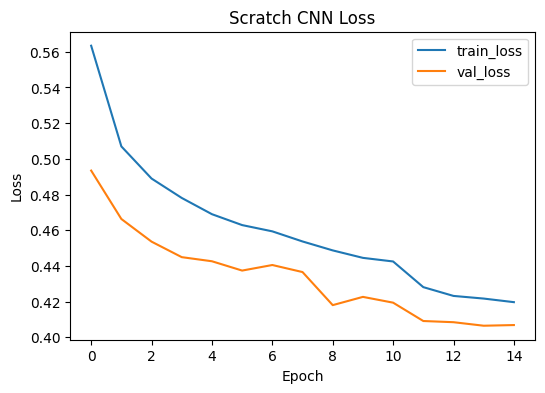

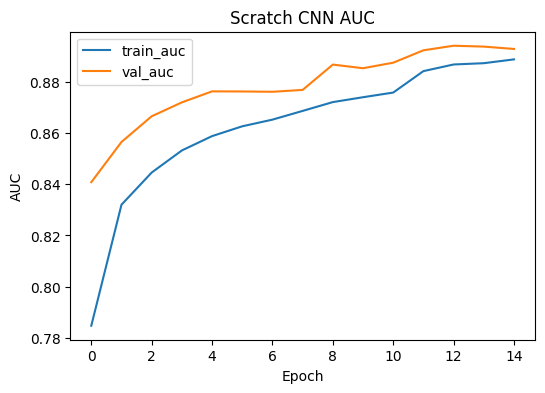

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_scratch.history['loss'], label='train_loss')
plt.plot(history_scratch.history['val_loss'], label='val_loss')
plt.title("Scratch CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_scratch.history['auc'], label='train_auc')
plt.plot(history_scratch.history['val_auc'], label='val_auc')
plt.title("Scratch CNN AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

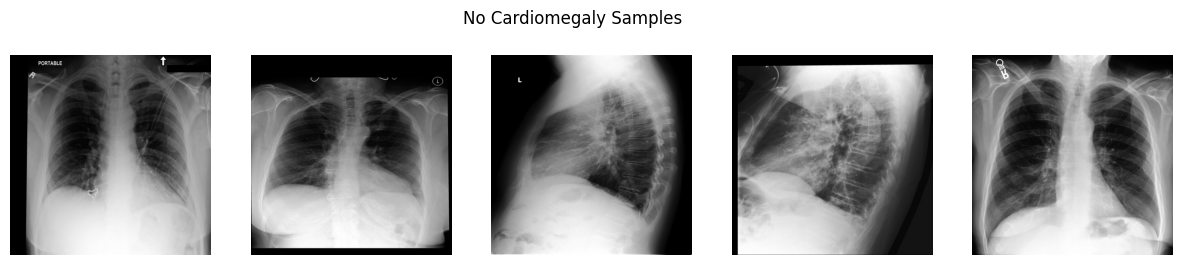

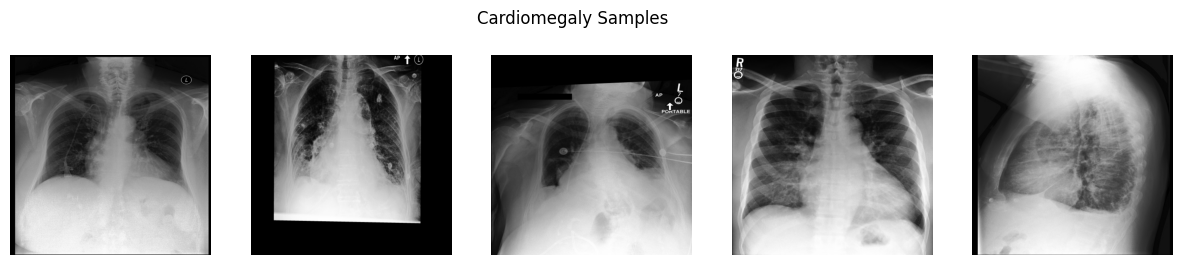

In [ ]:
import matplotlib.pyplot as plt
import cv2

def show_samples(df, label, n=5):
    subset = df[df["target"] == label].sample(n)

    plt.figure(figsize=(15,3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img = cv2.imread(row["path"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(1, n, i+1)
        plt.imshow(img)
        plt.axis("off")

    plt.suptitle(f"{'Cardiomegaly' if label==1 else 'No Cardiomegaly'} Samples")
    plt.show()

show_samples(binary_df, 0)
show_samples(binary_df, 1)

In [ ]:
import numpy as np

# Get predictions
preds = scratch_model.predict(test_gen).ravel()

# Convert to binary predictions
pred_labels = (preds >= 0.5).astype(int)

# True labels
true_labels = test_df["target"].values

print("Pred shape:", preds.shape)
print("True shape:", true_labels.shape)

310/310 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step
Pred shape: (9913,)
True shape: (9913,)


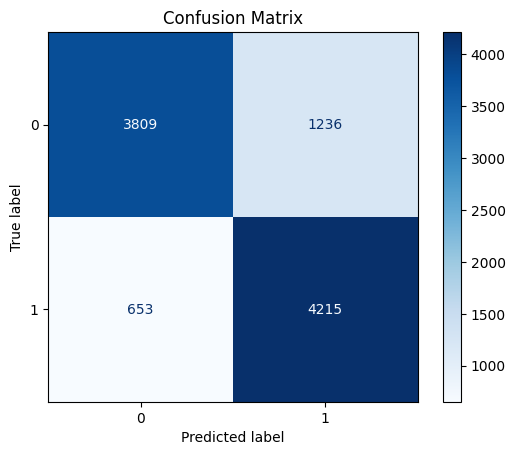

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

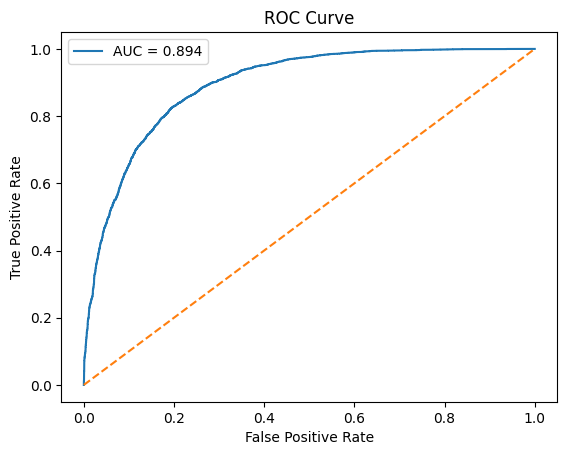

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(true_labels, preds)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [ ]:
import os

for root, dirs, files in os.walk(path):
    for file in files:
        if "patient" in file.lower() or "demo" in file.lower():
            print(os.path.join(root, file))

In [ ]:
import pandas as pd

# MMIC
try:
    patients_df = pd.read_csv(f"{path}/patients.csv")
    print("Loaded patients.csv")
    display(patients_df.head())
except:
    print("patients.csv not found")

patients.csv not found


### **DenseNet121**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121

def build_densenet121(input_shape=(224, 224, 3)):
    base_model = DenseNet121(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    # Freeze backbone initially
    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    return model

dense_model = build_densenet121()
dense_model.summary()

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,304,257 (27.86 MB)

 Trainable params: 264,705 (1.01 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint = ModelCheckpoint(
    "/content/densenet_stage1.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    checkpoint
]

In [ ]:
history_dense_1 = dense_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 367ms/step - accuracy: 0.7495 - auc: 0.8233 - loss: 0.5253
Epoch 1: val_loss improved from None to 0.48242, saving model to /content/densenet_stage1.keras

Epoch 1: finished saving model to /content/densenet_stage1.keras
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 1002s 387ms/step - accuracy: 0.7628 - auc: 0.8371 - loss: 0.4991 - val_accuracy: 0.7715 - val_auc: 0.8538 - val_loss: 0.4824 - learning_rate: 0.0010
Epoch 2/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7795 - auc: 0.8556 - loss: 0.4706
Epoch 2: val_loss improved from 0.48242 to 0.47628, saving model to /content/densenet_stage1.keras

Epoch 2: finished saving model to /content/densenet_stage1.keras
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 942s 374ms/step - accuracy: 0.7789 - auc: 0.8554 - loss: 0.4706 - val_accuracy: 0.7744 - val_auc: 0.8575 - val_loss: 0.4763 - learning_rate: 0.0010
Epoch 3/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step - accuracy: 0.7801 - auc: 0.8566 - loss: 0.4696
Epoch

In [ ]:
# Unfreeze top layers
for layer in dense_model.layers[1].layers[-50:]:
    layer.trainable = True

dense_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

checkpoint_ft = ModelCheckpoint(
    "/content/densenet_finetuned.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks_ft = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    checkpoint_ft
]

In [ ]:
history_dense_2 = dense_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks_ft,
    verbose=1
)

Epoch 1/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7884 - auc: 0.8690 - loss: 0.4504
Epoch 1: val_loss improved from None to 0.46107, saving model to /content/densenet_finetuned.keras

Epoch 1: finished saving model to /content/densenet_finetuned.keras
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 1014s 388ms/step - accuracy: 0.7912 - auc: 0.8707 - loss: 0.4481 - val_accuracy: 0.7872 - val_auc: 0.8665 - val_loss: 0.4611 - learning_rate: 1.0000e-05
Epoch 2/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 369ms/step - accuracy: 0.7979 - auc: 0.8777 - loss: 0.4365
Epoch 2: val_loss improved from 0.46107 to 0.45301, saving model to /content/densenet_finetuned.keras

Epoch 2: finished saving model to /content/densenet_finetuned.keras
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 953s 379ms/step - accuracy: 0.7980 - auc: 0.8782 - loss: 0.4358 - val_accuracy: 0.7894 - val_auc: 0.8712 - val_loss: 0.4530 - learning_rate: 1.0000e-05
Epoch 3/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 364ms/step - accuracy: 0.7981 - auc: 0.8795 

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

preds_dense = dense_model.predict(test_gen).ravel()
pred_labels_dense = (preds_dense >= 0.5).astype(int)
true_labels = test_df["target"].values

print("DenseNet ROC-AUC:", roc_auc_score(true_labels, preds_dense))
print(confusion_matrix(true_labels, pred_labels_dense))
print(classification_report(true_labels, pred_labels_dense, digits=4))

310/310 ━━━━━━━━━━━━━━━━━━━━ 53s 131ms/step
DenseNet ROC-AUC: 0.8859181092435949
[[3734 1311]
 [ 631 4237]]
              precision    recall  f1-score   support

           0     0.8554    0.7401    0.7936      5045
           1     0.7637    0.8704    0.8136      4868

    accuracy                         0.8041      9913
   macro avg     0.8096    0.8053    0.8036      9913
weighted avg     0.8104    0.8041    0.8034      9913



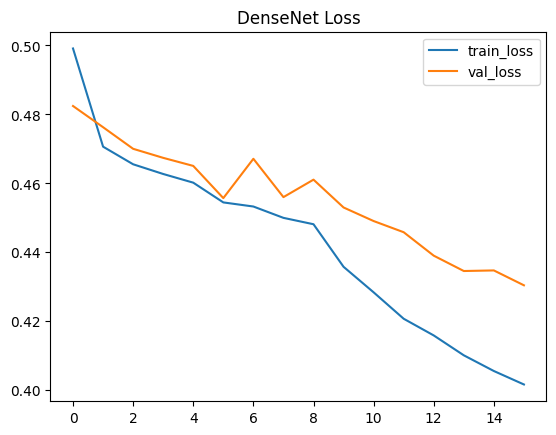

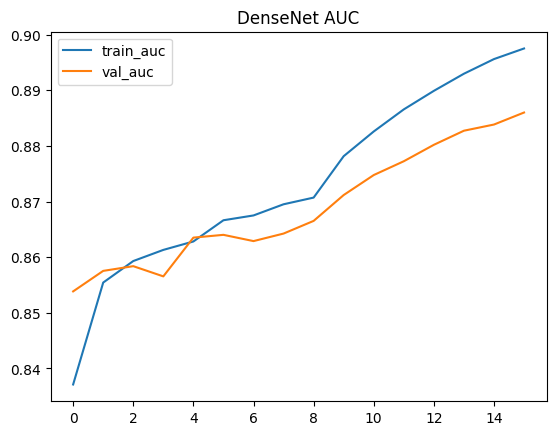

In [ ]:
import matplotlib.pyplot as plt

# Loss
plt.plot(history_dense_1.history['loss'] + history_dense_2.history['loss'], label="train_loss")
plt.plot(history_dense_1.history['val_loss'] + history_dense_2.history['val_loss'], label="val_loss")
plt.title("DenseNet Loss")
plt.legend()
plt.show()

# AUC
plt.plot(history_dense_1.history['auc'] + history_dense_2.history['auc'], label="train_auc")
plt.plot(history_dense_1.history['val_auc'] + history_dense_2.history['val_auc'], label="val_auc")
plt.title("DenseNet AUC")
plt.legend()
plt.show()

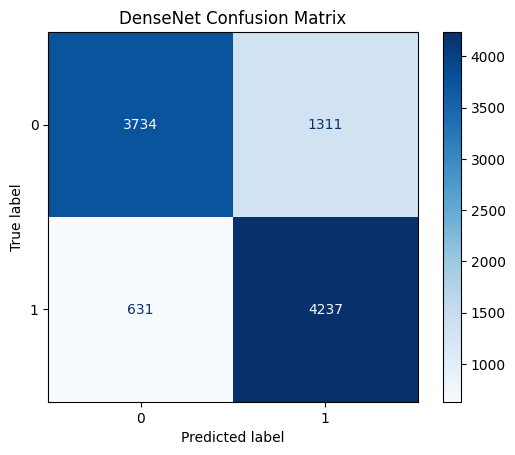

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_dense = confusion_matrix(true_labels, pred_labels_dense)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_dense)
disp.plot(cmap="Blues")
plt.title("DenseNet Confusion Matrix")
plt.show()

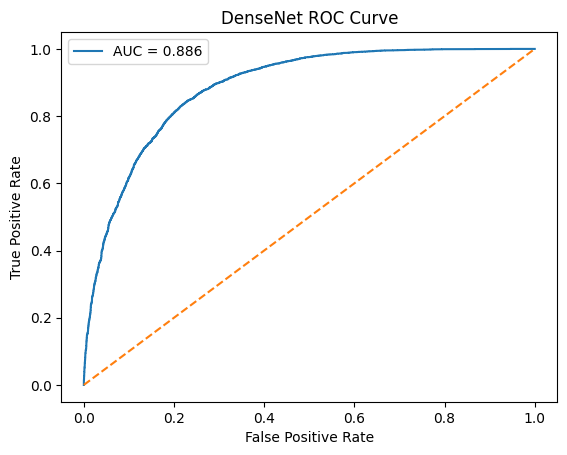

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_dense, tpr_dense, _ = roc_curve(true_labels, preds_dense)
roc_auc_dense = auc(fpr_dense, tpr_dense)

plt.plot(fpr_dense, tpr_dense, label=f"AUC = {roc_auc_dense:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("DenseNet ROC Curve")
plt.legend()
plt.show()

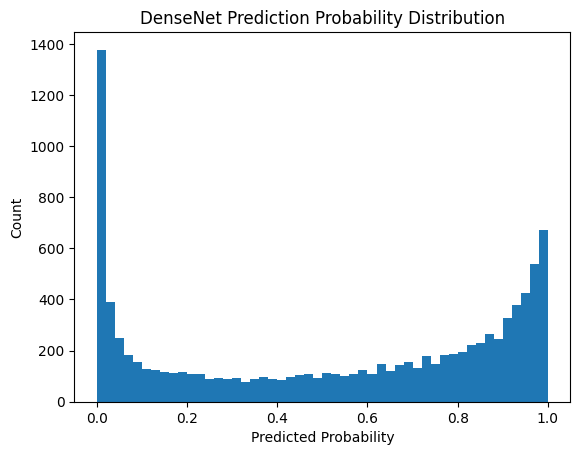

In [ ]:
plt.hist(preds_dense, bins=50)
plt.title("DenseNet Prediction Probability Distribution")
plt.xlabel("Predicted Probability")
plt.ylabel("Count")
plt.show()

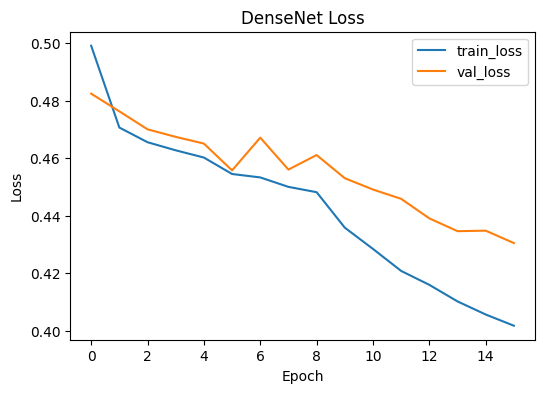

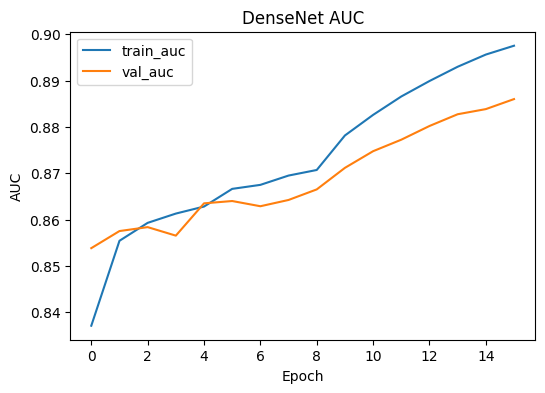

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history_dense_1.history['loss'] + history_dense_2.history['loss'], label='train_loss')
plt.plot(history_dense_1.history['val_loss'] + history_dense_2.history['val_loss'], label='val_loss')
plt.title("DenseNet Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_dense_1.history['auc'] + history_dense_2.history['auc'], label='train_auc')
plt.plot(history_dense_1.history['val_auc'] + history_dense_2.history['val_auc'], label='val_auc')
plt.title("DenseNet AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

### **VGGNet16**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import VGG16

def build_vgg16(input_shape=(224, 224, 3)):
    base_model = VGG16(
        weights="imagenet",
        include_top=False,
        input_shape=input_shape
    )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
    )

    return model

vgg_model = build_vgg16()
vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,321 (56.64 MB)

 Trainable params: 132,609 (518.00 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

In [ ]:
history_vgg_1 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks_vgg,
    verbose=1
)

NameError: name 'train_gen' is not defined

In [ ]:
history_vgg_1 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks_vgg,
    verbose=1
)

Epoch 1/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7410 - auc: 0.8159 - loss: 0.5279
Epoch 1: val_loss improved from None to 0.47104, saving model to /content/vgg16_stage1.keras

Epoch 1: finished saving model to /content/vgg16_stage1.keras
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 947s 374ms/step - accuracy: 0.7567 - auc: 0.8320 - loss: 0.5040 - val_accuracy: 0.7764 - val_auc: 0.8545 - val_loss: 0.4710 - learning_rate: 0.0010
Epoch 2/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 365ms/step - accuracy: 0.7703 - auc: 0.8474 - loss: 0.4816
Epoch 2: val_loss did not improve from 0.47104
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 942s 374ms/step - accuracy: 0.7726 - auc: 0.8491 - loss: 0.4795 - val_accuracy: 0.7688 - val_auc: 0.8588 - val_loss: 0.4716 - learning_rate: 0.0010
Epoch 3/8
2518/2518 ━━━━━━━━━━━━━━━━━━━━ 0s 363ms/step - accuracy: 0.7770 - auc: 0.8529 - loss: 0.4749
Epoch 3: val_loss improved from 0.47104 to 0.46293, saving model to /content/vgg16_stage1.keras

Epoch 3: finished saving model to

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

checkpoint_vgg = ModelCheckpoint(
    "/content/vgg16_stage1.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks_vgg = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    checkpoint_vgg
]

In [ ]:
ModelCheckpoint("/content/vgg16_stage1.keras", ...)

In [ ]:
import tensorflow as tf

vgg_model = tf.keras.models.load_model("/content/vgg16_stage1.keras")

ValueError: File not found: filepath=/content/vgg16_stage1.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
for layer in vgg_model.layers[1].layers[-4:]:
    layer.trainable = True

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

checkpoint_vgg_ft = ModelCheckpoint(
    "/content/vgg16_finetuned.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

callbacks_vgg_ft = [
    EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2),
    checkpoint_vgg_ft
]

In [ ]:
history_vgg_2 = vgg_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=8,
    callbacks=callbacks_vgg_ft,
    verbose=1
)

NameError: name 'train_gen' is not defined

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import numpy as np

preds_vgg = vgg_model.predict(test_gen).ravel()
pred_labels_vgg = (preds_vgg >= 0.5).astype(int)
true_labels = test_df["target"].values

print("VGG16 ROC-AUC:", roc_auc_score(true_labels, preds_vgg))
print(confusion_matrix(true_labels, pred_labels_vgg))
print(classification_report(true_labels, pred_labels_vgg, digits=4))

NameError: name 'test_gen' is not defined

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_vgg_1.history['loss'] + history_vgg_2.history['loss'], label="train_loss")
plt.plot(history_vgg_1.history['val_loss'] + history_vgg_2.history['val_loss'], label="val_loss")
plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_vgg_1.history['auc'] + history_vgg_2.history['auc'], label="train_auc")
plt.plot(history_vgg_1.history['val_auc'] + history_vgg_2.history['val_auc'], label="val_auc")
plt.title("VGG16 AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

NameError: name 'history_vgg_1' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
for name in ["train_df", "val_df", "test_df", "train_gen", "val_gen", "test_gen",
             "scratch_model", "dense_model", "vgg_model",
             "preds", "preds_dense", "pred_labels", "pred_labels_dense"]:
    print(name, name in globals())

train_df False
val_df False
test_df False
train_gen False
val_gen False
test_gen False
scratch_model False
dense_model False
vgg_model True
preds False
preds_dense False
pred_labels False
pred_labels_dense False


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.05,
    height_shift_range=0.05,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="path",
    y_col="target",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw"
)

val_gen = val_test_datagen.flow_from_dataframe(
    val_df,
    x_col="path",
    y_col="target",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

test_gen = val_test_datagen.flow_from_dataframe(
    test_df,
    x_col="path",
    y_col="target",
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="raw",
    shuffle=False
)

TypeError: All values in column x_col=path must be strings.

In [ ]:
print(os.path.exists("/content/train_df.csv"))
print(os.path.exists("/content/val_df.csv"))
print(os.path.exists("/content/test_df.csv"))
print(os.path.exists("/content/densenet_finetuned.keras"))
print(os.path.exists("/content/densenet_stage1.keras"))
print(os.path.exists("/content/vgg16_stage1.keras"))

False
False
False
False
False
False


In [ ]:
train_df = pd.read_csv("/content/train_df.csv")
val_df = pd.read_csv("/content/val_df.csv")
test_df = pd.read_csv("/content/test_df.csv")

FileNotFoundError: [Errno 2] No such file or directory: '/content/train_df.csv'

In [ ]:
for name in ["train_df", "val_df", "test_df", "train_gen", "val_gen", "test_gen"]:
    print(name, name in globals())

print(os.path.exists("/content/densenet_finetuned.keras"))
print(os.path.exists("/content/vgg16_stage1.keras"))

train_df True
val_df True
test_df True
train_gen False
val_gen False
test_gen False
False
False


In [ ]:
print("history_vgg_1" in globals())
print("history_vgg_2" in globals())

False
False


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_vgg_1.history['loss'] + history_vgg_2.history['loss'], label="train_loss")
plt.plot(history_vgg_1.history['val_loss'] + history_vgg_2.history['val_loss'], label="val_loss")
plt.title("VGG16 Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history_vgg_1.history['auc'] + history_vgg_2.history['auc'], label="train_auc")
plt.plot(history_vgg_1.history['val_auc'] + history_vgg_2.history['val_auc'], label="val_auc")
plt.title("VGG16 AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.legend()
plt.show()

NameError: name 'history_vgg_1' is not defined

<Figure size 600x400 with 0 Axes>

In [ ]:
sample_row = test_df.sample(1).iloc[0]

img_path = sample_row["path"]
true_label = sample_row["target"]

print("Path:", img_path)
print("True label:", true_label)

Path: nan
True label: 1


In [ ]:
import cv2
import numpy as np

IMG_SIZE = (224, 224)

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img_resized = cv2.resize(img, IMG_SIZE)

img_array = img_resized / 255.0
img_array = np.expand_dims(img_array, axis=0)

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object


In [ ]:
import tensorflow as tf

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, 0]

    grads = tape.gradient(loss, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

In [ ]:
for dense_model in layers.Dense:
    print(layer.name)

TypeError: 'type' object is not iterable

In [ ]:
heatmap = make_gradcam_heatmap(img_array, scratch_model, "conv2d_2")

NameError: name 'img_array' is not defined

In [ ]:
import tensorflow as tf

scratch_model = tf.keras.models.load_model("/content/scratch_model.keras")

ValueError: File not found: filepath=/content/scratch_model.keras. Please ensure the file is an accessible `.keras` zip file.